In [1]:
# jax_climate_emissions.py
from __future__ import annotations
import jax
import jax.numpy as jnp
from jax import lax

# --------------------------
# Defaults (same physics)
# --------------------------
DEFAULT_PARAMS = {
    "ecs": 3.0,                             # Equilibrium Climate Sensitivity [K]
    "ohtr": 1.23,                           # Ocean heat transport coefficient
    "a": jnp.array([0.2173, 0.2240, 0.2824, 0.2763]),   # Carbon reservoir fractions [-]
    "tau": jnp.array([1e6, 394.4, 36.54, 4.304]),       # Reservoir time scales [yr]
    "ch4_tau": 11.8, # CH4 lifetime
    "k_ch4": 0.036, #
}

# Constants used in both the original and this rewrite
C0_PI      = 277.15   # Preindustrial CO2 [ppm]
SPY        = 3600.0 * 24.0 * 365.25
EARTHAREA  = 5.1e14   # m^2
LFRAC      = 0.292
LTHK       = 8.4      # m
OTHK       = 100.0    # m
OMHC       = 4186.0   # J kg^-1 K^-1
ODENS      = 1000.0   # kg m^-3
DTHK       = jnp.array([300., 300., 1300., 1800.])  # m
C_MIN      = 1e-6     # ppm, to keep log well-defined
PPM_TO_GTC = 2.12     # 1 ppm = 2.12 GtC

GTCO2_TO_PPM_PER_YEAR = (12.0 / 44.0) / PPM_TO_GTC  # ≈ 0.1276 ppm per GtCO2

M0_CH4_PI      = 722.0      # preindustrial CH4 [ppb]
PPB_TO_MTCH4   = 2.78       # 1 ppb CH4 ≈ 2.78 Mt CH4 in the atmosphere
MTCH4_PER_PPB  = PPB_TO_MTCH4
PPB_PER_MTCH4  = 1.0 / MTCH4_PER_PPB

# --------------------------
# Carbon cycle step (Joos-like 4-box)
# --------------------------
def carbon_step(cpool: jnp.ndarray,
                Et: float,
                params: dict,
                dt: float) -> jnp.ndarray:
    """
    cpool: shape (4,), reservoir carbon anomalies (ppm) contributing to Catm
    Et:    emissions input in ppm/year, held constant within substep (matches original)
    """
    a   = params["a"]
    tau = params["tau"]
    dydt = a * Et - cpool / tau
    return cpool + dt * dydt

# --------------------------
# Radiative forcing (piecewise), AR6-like
# --------------------------
def radiative_forcing_co2(C: jnp.ndarray) -> jnp.ndarray:
    """
    Piecewise polynomial coefficient in front of log(C/C0).
    Matches the original structure and is JAX-friendly via jnp.where.
    """
    a1 = -2.4785e-7   # W m^-2 ppm^-2
    b1 = 7.5906e-4    # W m^-2 ppm^-1
    d1 = 5.2488       # W m^-2
    C0 = C0_PI

    Camax = C0 - b1 / (2.0 * a1)

    C = jnp.clip(C, C_MIN, jnp.inf)   # safety for log
    # build coefC via masks (same logic as original)
    coef_hi = d1 - (b1 ** 2) / (d1 * a1)                             # C >= Camax
    coef_mid = d1 + a1 * (C - C0) ** 2 + b1 * (C - C0)               # C0 < C < Camax
    coef_lo = d1                                                     # C <= C0

    coefC = jnp.where(C >= Camax, coef_hi,
             jnp.where(C > C0,   coef_mid, coef_lo))
    return coefC * jnp.log(C / C0)

def radiative_forcing_ch4(M_ppb: jnp.ndarray, params: dict) -> jnp.ndarray:
    """
    Simple CH4 ERF without N2O overlap:
      RF = k_ch4 * (sqrt(M) - sqrt(M0))
    Pass k_ch4 via params; keep it differentiable.
    """
    k = params["k_ch4"]
    M = jnp.clip(M_ppb, 1e-6, jnp.inf)
    return k * (jnp.sqrt(M) - jnp.sqrt(M0_CH4_PI))

def methane_step(m_anom_ppb: float,
                 E_mtCH4_per_year: float,
                 params: dict,
                 dt: float) -> jnp.ndarray:
    """
    Single-reservoir CH4 anomaly (in ppb) relative to PI.
    d(m)/dt = E_ppb - m/tau
      where E_ppb = E_mtCH4 / 2.78  (MtCH4->ppb)
    """
    tau = params["ch4_tau"]
    E_ppb_per_year = E_mtCH4_per_year * PPB_PER_MTCH4
    dm_dt = E_ppb_per_year - (m_anom_ppb / tau)
    return m_anom_ppb + dt * dm_dt

# --------------------------
# Climate step (same math/order as original _climateModel)
# --------------------------
def climate_step(RF_prev: float,
                 tanm_ao: float,
                 tanm_d: jnp.ndarray,
                 params: dict,
                 dt: float) -> tuple[float, jnp.ndarray]:
    """
    One Euler step for the atmosphere+ocean column with previous-step RF.
    Returns (new_tanm_ao, new_tanm_d).
    """
    ecs  = params["ecs"]
    ohtr = params["ohtr"]

    # Heat capacities per unit area
    ao_vol  = EARTHAREA * (LFRAC * LTHK + (1.0 - LFRAC) * OTHK)
    ao_vhc  = OMHC * ODENS
    ao_hc   = (ao_vol * ao_vhc) / EARTHAREA

    d_vol = (1.0 - LFRAC) * EARTHAREA * DTHK
    d_vhc = ao_vhc
    d_hc  = (d_vol * d_vhc) / EARTHAREA

    layert  = jnp.concatenate([jnp.array([OTHK]), DTHK])
    mlayerT = 0.5 * (layert[:-1] + layert[1:])
    htc     = ohtr * mlayerT[0]

    # Feedback parameter from 2xCO2
    fbparam = radiative_forcing_co2(2.0 * C0_PI) / ecs

    # Energy (per area) states
    aoQ = tanm_ao * ao_hc
    dQ  = tanm_d  * d_hc

    # Flux terms
    feedcooling = tanm_ao * fbparam
    # vertical heat transport between layers
    htr0   = (tanm_ao - tanm_d[0]) * htc / mlayerT[0]
    # deeper layers (finite-volume-ish stencil)
    # htr array length = 1 + len(DTHK)
    # Build htr explicitly (JAX-friendly):
    # htr[0] defined above; then for j>=1:
    htr_rest = ((dQ[:-1] / d_hc[:-1]) - (dQ[1:] / d_hc[1:])) * htc / mlayerT[1:]
    htr = jnp.concatenate([jnp.array([htr0]), htr_rest])

    # Euler updates
    aoQnew = aoQ + dt * (RF_prev - feedcooling - htr[0]) * SPY
    # deep ocean layers
    dQnew = dQ.at[:-1].add(dt * (htr[:-1] - htr[1:]) * SPY)
    dQnew = dQnew.at[-1].add(dt * htr[-1] * SPY)

    # back to temperatures
    tanm_ao_new = aoQnew / ao_hc
    tanm_d_new  = dQnew  / d_hc
    return tanm_ao_new, tanm_d_new

# --------------------------
# Time integration via lax.scan (no NaNs, JIT/grad-safe)
# --------------------------
def simulate_emissions_two_gases(
    years: jnp.ndarray,
    emissions_co2_GtCO2_per_year: jnp.ndarray,   # (T,)
    emissions_ch4_MtCH4_per_year: jnp.ndarray,   # (T,)
    params: dict | None = None,
    dt: float = 0.1
):
    if params is None:
        params = DEFAULT_PARAMS

    years  = jnp.asarray(years, dtype=jnp.float32)
    eco2   = jnp.asarray(emissions_co2_GtCO2_per_year, dtype=jnp.float32)
    ech4   = jnp.asarray(emissions_ch4_MtCH4_per_year, dtype=jnp.float32)

    # Fine time grid
    start = years[0]
    end   = years[-1]
    nsteps = jnp.int32(jnp.floor((end - start) / dt) + 1)
    tvec = start + jnp.arange(nsteps + 1, dtype=jnp.float32) * dt  # inclusive end

    # Initial states
    cpool0     = jnp.zeros((4,), dtype=jnp.float32)   # CO2 pools [ppm]
    m_anom0    = jnp.float32(0.0)                     # CH4 anomaly [ppb]
    tanm_ao0   = jnp.float32(0.0)
    tanm_d0    = jnp.zeros((4,), dtype=jnp.float32)
    RF_prev0   = jnp.float32(0.0)

    # Precompute CO2 emissions in ppm/yr (held piecewise-constant)
    emis_co2_ppm = eco2 * GTCO2_TO_PPM_PER_YEAR

    def step_fn(carry, t_curr):
        cpool, m_anom, tanm_ao, tanm_d, RF_prev = carry

        # --- emissions lookup (hold-last) ---
        idx = jnp.searchsorted(years, t_curr + (dt/10.0), side='right') - 1
        idx = jnp.clip(idx, 0, years.shape[0]-1)

        Et_co2_ppm_per_year  = emis_co2_ppm[idx]
        Et_ch4_mt_per_year   = ech4[idx]

        # --- CO2 carbon pools -> Catm (ppm) ---
        cpool_new = carbon_step(cpool, Et_co2_ppm_per_year, params, dt)
        Catm_ppm  = C0_PI + jnp.sum(cpool_new)

        # --- CH4 1-box -> Matm (ppb) ---
        m_anom_new = methane_step(m_anom, Et_ch4_mt_per_year, params, dt)
        Matm_ppb   = M0_CH4_PI + m_anom_new

        # --- ERFs ---
        RF_co2 = radiative_forcing_co2(Catm_ppm)                # existing CO2 RF
        RF_ch4 = radiative_forcing_ch4(Matm_ppb, params)    # new CH4 RF
        RF_curr = RF_co2 + RF_ch4

        # --- climate advance using previous RF ---
        tanm_ao_new, tanm_d_new = climate_step(RF_prev, tanm_ao, tanm_d, params, dt)

        new_carry = (cpool_new, m_anom_new, tanm_ao_new, tanm_d_new, RF_curr)
        y = jnp.stack([Catm_ppm, Matm_ppb, RF_co2, RF_ch4, tanm_ao_new], axis=0)
        return new_carry, y

    carry0 = (cpool0, m_anom0, tanm_ao0, tanm_d0, RF_prev0)
    carry_f, Y = lax.scan(step_fn, carry0, tvec[:-1])  # (nsteps, 5)

    Catm_full = Y[:, 0]   # ppm
    Matm_full = Y[:, 1]   # ppb
    RFc_full  = Y[:, 2]
    RFm_full  = Y[:, 3]
    GMST_full = Y[:, 4]

    # Sample to year ticks (hold-last)
    year_indices = jnp.searchsorted(tvec[:-1], years, side='right') - 1
    year_indices = jnp.clip(year_indices, 0, GMST_full.shape[0]-1)

    Catm_years = Catm_full[year_indices]
    Matm_years = Matm_full[year_indices]
    RFc_years  = RFc_full[year_indices]
    RFm_years  = RFm_full[year_indices]
    GMST_years = GMST_full[year_indices]

    # Diagnostics
    emissions_ppm_co2 = emis_co2_ppm
    cumulative_GtC = jnp.cumsum(emissions_ppm_co2 * PPM_TO_GTC)     # GtC
    cumulative_MtCH4 = jnp.cumsum(ech4)                              # MtCH4

    return {
        "years": years,
        # Atmosphere
        "Catm_ppm": Catm_years,
        "Matm_ppb": Matm_years,
        # Forcing
        "RF_co2": RFc_years,
        "RF_ch4": RFm_years,
        "RF_total": RFc_years + RFm_years,
        # Temperature
        "GMST": GMST_years,
        # Emissions diagnostics
        "emissions_co2_GtCO2_per_year": emissions_co2_GtCO2_per_year,
        "emissions_ch4_MtCH4_per_year": emissions_ch4_MtCH4_per_year,
        "cumulative_GtC": cumulative_GtC,
        "cumulative_MtCH4": cumulative_MtCH4,
        # Optional sub-annual outputs
        "t_sub": tvec[1:],
        "Catm_sub": Catm_full,
        "Matm_sub": Matm_full,
        "RF_co2_sub": RFc_full,
        "RF_ch4_sub": RFm_full,
        "GMST_sub": GMST_full,
    }

# --------------------------
# Convenience wrappers
# --------------------------
def loss_mse_GMST_two_gases(e_co2_gtco2, e_ch4_mt, years, target_gmst, params=None, dt=0.1):
    out = simulate_emissions_two_gases(years, e_co2_gtco2, e_ch4_mt, params, dt)
    pred = out["GMST"]
    return jnp.mean((pred - target_gmst)**2)

# grads wrt (CO2_emis, CH4_emis)
loss_and_grads = jax.value_and_grad(loss_mse_GMST_two_gases, argnums=(0, 1))


In [32]:
import run_fair

agents = ['CO2','CH4']
start, stop = 1750, 2500
years = jnp.arange(start, stop)

emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(agents)
E_gtco2 = jnp.concatenate((emis_dict_tier1['historical']['CO2'], emis_dict_tier1['H-ext']['CO2']))
E_mtch4 = jnp.concatenate((emis_dict_tier1['historical']['CH4'], emis_dict_tier1['H-ext']['CH4']))
out = simulate_emissions_two_gases(years, emissions_co2_GtCO2_per_year=E_gtco2, emissions_ch4_MtCH4_per_year=E_mtch4,params=DEFAULT_PARAMS, dt=0.1)

emis_dict_DECK = run_fair.load_DECK_CMIP7(agents)
scenarios_DECK = list(emis_dict_DECK.keys())
delT_dict_DECK = run_fair.get_delT(emis_dict_DECK, scenarios_DECK, agents, MIP='DECK')

scenarios_DECK_subset = []
for scen in scenarios_DECK:
  if scen == 'historical':
    continue
  for a in agents:
    if a not in scen:
      continue
    else:
      scenarios_DECK_subset.append(scen)

In [6]:
def _as_jnp(x):
    return x if isinstance(x, jnp.ndarray) else jnp.asarray(x, dtype=jnp.float32)


In [7]:
def make_features_E_and_cum_co2_ch4(
    E_gtco2_curr,                 # (T_cur,)
    E_mtch4_curr,                 # (T_cur,)
    E_gtco2_hist=None,            # (T_hist,) or None
    E_mtch4_hist=None             # (T_hist,) or None
):
    """
    Causal features aligned to GMST at integer years:
      X[t, 0] = E_CO2_{t-1}      (GtCO2/yr)
      X[t, 1] = CumE_CO2_{t-1}   (GtCO2)
      X[t, 2] = E_CH4_{t-1}      (MtCH4/yr)
      X[t, 3] = CumE_CH4_{t-1}   (MtCH4)

    If history is provided, year 0 uses the last historical year (no leakage).
    If no history, year 0 uses zeros.
    """
    Ec  = _as_jnp(E_gtco2_curr).reshape(-1)   # (T_cur,)
    Em  = _as_jnp(E_mtch4_curr).reshape(-1)   # (T_cur,)
    T   = Ec.shape[0]

    # --- CO2 features ---
    if E_gtco2_hist is not None:
        Eh = _as_jnp(E_gtco2_hist).reshape(-1)
        H  = Eh.shape[0]
        E_all   = jnp.concatenate([Eh, Ec], axis=0)
        E_prevC = E_all[(H-1):(H-1+T)]
        Cum_all = jnp.cumsum(E_all)
        Cum_prevC = Cum_all[(H-1):(H-1+T)]
    else:
        zero = jnp.array([0.0], dtype=Ec.dtype)
        E_prevC   = jnp.concatenate([zero, Ec[:-1]], axis=0)
        CumC      = jnp.cumsum(Ec)
        Cum_prevC = jnp.concatenate([zero, CumC[:-1]], axis=0)

    # --- CH4 features ---
    if E_mtch4_hist is not None:
        Mh = _as_jnp(E_mtch4_hist).reshape(-1)
        Hm = Mh.shape[0]
        M_all   = jnp.concatenate([Mh, Em], axis=0)
        E_prevM = M_all[(Hm-1):(Hm-1+T)]
        CumM_all = jnp.cumsum(M_all)
        Cum_prevM = CumM_all[(Hm-1):(Hm-1+T)]
    else:
        zeroM = jnp.array([0.0], dtype=Em.dtype)
        E_prevM   = jnp.concatenate([zeroM, Em[:-1]], axis=0)
        CumM      = jnp.cumsum(Em)
        Cum_prevM = jnp.concatenate([zeroM, CumM[:-1]], axis=0)

    X = jnp.stack([E_prevC, Cum_prevC, E_prevM, Cum_prevM], axis=1)  # (T, 4)
    return X


In [15]:
def _infer_step(yrs: jnp.ndarray) -> jnp.ndarray:
    yrs = _as_jnp(yrs).reshape(-1)
    if yrs.size <= 1:
        return jnp.array(1.0, dtype=jnp.float32)
    return jnp.median(jnp.diff(yrs))

def _make_contiguous_years(yrs_hist: jnp.ndarray, yrs_curr: jnp.ndarray):
    """
    Rebase yrs_curr so its first point is exactly one step after yrs_hist[-1].
    Keeps the *spacing* of yrs_curr. If yrs_curr already follows yrs_hist,
    we leave it unchanged.
    """
    yrs_h = _as_jnp(yrs_hist).reshape(-1)
    yrs_c = _as_jnp(yrs_curr).reshape(-1)

    if (yrs_h.size == 0) or (yrs_c.size == 0):
        return jnp.concatenate([yrs_h, yrs_c]), yrs_c

    # If already contiguous (or strictly after), do nothing
    if yrs_c[0] > yrs_h[-1]:
        yrs_all = jnp.concatenate([yrs_h, yrs_c])
        return yrs_all, yrs_c

    # Otherwise, shift current so it starts one "curr step" after hist end
    step_c   = _infer_step(yrs_c)
    shift    = (yrs_h[-1] + step_c) - yrs_c[0]
    yrs_c_rb = yrs_c + shift
    yrs_all  = jnp.concatenate([yrs_h, yrs_c_rb])
    return yrs_all, yrs_c_rb

In [16]:
def simulate_targets_gmst_from_co2_ch4(
    years_curr,                  # (T_cur,)
    E_gtco2_curr,                # (T_cur,)
    E_mtch4_curr,                # (T_cur,)
    years_hist=None,             # (T_hist,) or None
    E_gtco2_hist=None,           # (T_hist,) or None
    E_mtch4_hist=None,           # (T_hist,) or None
    params=None,
    dt=0.1
):
    """
    Returns GMST over the current scenario's years using the TWO-GAS JAX simulator.
    """
    yrs_c = _as_jnp(years_curr).reshape(-1)
    Eco2_c = _as_jnp(E_gtco2_curr).reshape(-1)
    Ech4_c = _as_jnp(E_mtch4_curr).reshape(-1)

    if (years_hist is not None) and (E_gtco2_hist is not None) and (E_mtch4_hist is not None):
        yrs_h   = _as_jnp(years_hist).reshape(-1)
        Eco2_h  = _as_jnp(E_gtco2_hist).reshape(-1)
        Ech4_h  = _as_jnp(E_mtch4_hist).reshape(-1)

        yrs_all, yrs_c_rb = _make_contiguous_years(yrs_h, yrs_c)
        Eco2_all = jnp.concatenate([Eco2_h, Eco2_c], axis=0)
        Ech4_all = jnp.concatenate([Ech4_h, Ech4_c], axis=0)

        out_all = simulate_emissions_two_gases(
            yrs_all,
            emissions_co2_GtCO2_per_year=Eco2_all,
            emissions_ch4_MtCH4_per_year=Ech4_all,
            params=(params or DEFAULT_PARAMS),
            dt=dt
        )
        GMST_curr = out_all["GMST"][-Eco2_c.shape[0]:]
    else:
        out_c = simulate_emissions_two_gases(
            yrs_c,
            emissions_co2_GtCO2_per_year=Eco2_c,
            emissions_ch4_MtCH4_per_year=Ech4_c,
            params=(params or DEFAULT_PARAMS),
            dt=dt
        )
        GMST_curr = out_c["GMST"]

    return GMST_curr


In [17]:
import numpy as np
def extract_years_and_E_co2_ch4(emis_entry_for_scenario):
    """
    Adapter: from run_fair's emis_dict[scenario] to (years, E_gtco2, E_mtch4).
    Edit the TODO lines to match your dict structure.
    """
    # --- TODO: adjust these to your actual structure
    years    = jnp.asarray(np.arange(0, len(emis_entry_for_scenario['CO2'])), dtype=jnp.float32)
    E_gtco2  = jnp.asarray(emis_entry_for_scenario["CO2"], dtype=jnp.float32)  # GtCO2/yr
    E_mtch4  = jnp.asarray(emis_entry_for_scenario["CH4"], dtype=jnp.float32)  # MtCH4/yr
    # ---
    return years, E_gtco2, E_mtch4


In [60]:
def build_dataset_from_runfair_dict_2g(emis_dict, scenarios, historical_name="historical", skip_hist=False):
    """
    Returns list of tuples per scenario:
      (X_features, y_target, scenario_name)
    where:
      X_features = [E_CO2_prev, CumE_CO2_prev, E_CH4_prev, CumE_CH4_prev]
      y_target   = GMST from the TWO-GAS JAX simulator aligned to current years
    """
    # Extract historical series once, if present
    years_hist, E_hist_co2, E_hist_ch4 = (None, None, None)
    if historical_name in emis_dict:
        years_hist, E_hist_co2, E_hist_ch4 = extract_years_and_E_co2_ch4(emis_dict[historical_name])

    dataset = []
    for scen in scenarios:
        if skip_hist and scen == 'historical':
            continue
        years_cur, E_cur_co2, E_cur_ch4 = extract_years_and_E_co2_ch4(emis_dict[scen])
        needs_history = (scen != historical_name)

        # Features (original units)
        X = make_features_E_and_cum_co2_ch4(
            E_gtco2_curr=E_cur_co2,
            E_mtch4_curr=E_cur_ch4,
            E_gtco2_hist=E_hist_co2 if needs_history else None,
            E_mtch4_hist=E_hist_ch4 if needs_history else None
        )

        # Targets (two-gas simulator)
        y = simulate_targets_gmst_from_co2_ch4(
            years_curr=years_cur,
            E_gtco2_curr=E_cur_co2,
            E_mtch4_curr=E_cur_ch4,
            years_hist=years_hist if needs_history else None,
            E_gtco2_hist=E_hist_co2 if needs_history else None,
            E_mtch4_hist=E_hist_ch4 if needs_history else None
        )

        N = min(X.shape[0], y.shape[0])
        dataset.append((X[:N], y[:N], scen))

    return dataset


In [19]:
def fit_scaler(X: jnp.ndarray, eps: float = 1e-8):
    mu = jnp.mean(X, axis=0)
    sd = jnp.sqrt(jnp.var(X, axis=0) + eps)
    Xs = (X - mu) / sd
    return Xs, (mu, sd)

def apply_scaler(X: jnp.ndarray, stats):
    mu, sd = stats
    return (X - mu) / sd

def split_and_scale(train_dataset, test_dataset):
    """
    JAX-safe version: no NumPy calls on traced arrays.
    train_dataset / test_dataset: lists of (X, y, scen)
    Returns:
      train_scaled = [(X_s, y, scen), ...]
      test_scaled  = [(X_s, y, scen), ...]
      stats = (mu, sd)
    """
    # Concatenate train features along rows
    Xtr_list = [jnp.asarray(X, dtype=jnp.float32) for (X, _, _) in train_dataset]
    Xtr = jnp.concatenate(Xtr_list, axis=0) if Xtr_list else jnp.zeros((0,4), jnp.float32)


    # Fit scaler on the concatenated train features
    Xtr_s, stats = fit_scaler(Xtr)

    # Slice standardized rows back per scenario
    train_scaled = []
    offset = 0
    for (X, y, scen) in train_dataset:
        n = X.shape[0]  # Python int (static)
        Xs_slice = Xtr_s[offset:offset+n]
        train_scaled.append((Xs_slice, jnp.asarray(y, dtype=jnp.float32), scen))
        offset += n

    # Apply scaler to test features
    test_scaled = []
    for (X, y, scen) in test_dataset:
        Xs = apply_scaler(jnp.asarray(X, dtype=jnp.float32), stats)
        test_scaled.append((Xs, jnp.asarray(y, dtype=jnp.float32), scen))

    return train_scaled, test_scaled, stats

In [20]:
agents = ['CO2','CH4']#,'N2O','Sulfur','BC']
emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(agents)
scenarios_tier1, scenarios_tier2 = list(emis_dict_tier1.keys()), list(emis_dict_tier2.keys())
delT_dict_tier1 = run_fair.get_delT(emis_dict_tier1, scenarios_tier1, agents, MIP='ScenarioMIP_tier1')
delT_dict_tier2 = run_fair.get_delT(emis_dict_tier2, scenarios_tier2, agents, MIP='ScenarioMIP_tier2')

train_data = build_dataset_from_runfair_dict_2g(emis_dict_tier1, scenarios_tier1, historical_name="historical")
test_data  = build_dataset_from_runfair_dict_2g(emis_dict_tier2,  scenarios_tier2,  historical_name="historical")

In [21]:
import jax, jax.numpy as jnp
import optax

# ----- LSTM params: arrays only (no ints), with explicit dtype -----
def init_lstm_params(key, in_dim, hidden=32, out_dim=1, dtype=jnp.float32):
    kW, kO = jax.random.split(key)

    # Make weights/biases in the requested dtype
    W  = jax.random.normal(kW, (in_dim + hidden, 4 * hidden), dtype=dtype)
    b  = jnp.zeros((4 * hidden,), dtype=dtype)
    Wo = jax.random.normal(kO, (hidden, out_dim), dtype=dtype)
    bo = jnp.zeros((out_dim,), dtype=dtype)

    # Scale in SAME dtype (avoid float64 promotion)
    scale_W  = jnp.array(1.0, dtype=dtype) / jnp.sqrt(jnp.array(in_dim + hidden, dtype=dtype))
    scale_Wo = jnp.array(1.0, dtype=dtype) / jnp.sqrt(jnp.array(hidden,        dtype=dtype))
    W  = W  * scale_W
    Wo = Wo * scale_Wo

    return {"W": W, "b": b, "Wo": Wo, "bo": bo}

def _hidden_size_from_params(params):
    return params["b"].shape[0] // 4

def _lstm_cell(params, carry, x_t):
    h, c = carry
    hidden = _hidden_size_from_params(params)

    # z is in params dtype (since we cast X to params dtype in forward)
    z = jnp.concatenate([x_t, h], axis=-1) @ params["W"] + params["b"]
    i = jax.nn.sigmoid(z[..., 0*hidden:1*hidden])
    f = jax.nn.sigmoid(z[..., 1*hidden:2*hidden])
    g = jnp.tanh(      z[..., 2*hidden:3*hidden])
    o = jax.nn.sigmoid(z[..., 3*hidden:4*hidden])
    c_new = f * c + i * g
    h_new = o * jnp.tanh(c_new)
    return (h_new, c_new), h_new

def lstm_forward(params, X):
    """
    X: (N, D) or (N, T, D). If (N, D), treated as T=1.
    Returns: (N,) via linear readout on final hidden.
    """
    # Coerce inputs to params dtype to prevent promotion
    pdt = params["W"].dtype
    X = X.astype(pdt)
    if X.ndim == 2:
        X = X[:, None, :]

    N, T, D = X.shape
    hidden = _hidden_size_from_params(params)
    h0 = jnp.zeros((N, hidden), dtype=pdt)
    c0 = jnp.zeros((N, hidden), dtype=pdt)

    def step(carry, x_t):
        return _lstm_cell(params, carry, x_t)

    # time-major scan; outputs keep dtype pdt
    (hT, _), _ = jax.lax.scan(step, (h0, c0), X.swapaxes(0, 1))
    y = (hT @ params["Wo"] + params["bo"]).squeeze(-1)
    return y

def mse(pred, y):
    pred = pred.astype(y.dtype)
    return jnp.mean((pred - y)**2)

def train_unrolled_lstm(params0, Xtr, ytr, K=200, lr=1e-3, weight_decay=0.0):
    # Ensure feature/target dtypes match params
    pdt = params0["W"].dtype
    Xtr = Xtr.astype(pdt)
    ytr = ytr.astype(pdt)

    optimizer = optax.adamw(lr, weight_decay=weight_decay)
    opt_state = optimizer.init(params0)

    def step(carry, _):
        params, opt_state = carry
        def loss_fn(p):
            yhat = lstm_forward(p, Xtr)
            return mse(yhat, ytr)
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params=params)
        params = optax.apply_updates(params, updates)
        return (params, opt_state), loss

    (paramsK, opt_stateK), losses = jax.lax.scan(step, (params0, opt_state), xs=None, length=K)
    return paramsK, losses

def eval_on_tests_lstm(params, test_scaled_list):
    if not test_scaled_list:
        return jnp.array(0.0, dtype=jnp.float32)
    errs = [mse(lstm_forward(params, X), y) for (X, y, _) in test_scaled_list]
    return jnp.mean(jnp.stack(errs))

def plot_lstm_predictions(params, Xs, y, metric="RMSE", title_prefix="LSTM fit"):
    yhat = lstm_forward(params, Xs)
    loss_val = float(jnp.sqrt(jnp.mean((yhat - y)**2))) if metric.upper()=="RMSE" else float(jnp.mean((yhat - y)**2))

    import numpy as np, matplotlib.pyplot as plt
    plt.figure(figsize=(8,3))
    plt.plot(np.asarray(y),    label="truth", alpha=0.8)
    plt.plot(np.asarray(yhat), label="pred",  alpha=0.8)
    plt.legend(); plt.xlabel("time step"); plt.ylabel("target")
    plt.title(f"{title_prefix} - {metric.upper()}: {loss_val:.4f}")
    plt.tight_layout(); plt.show()



historical                      RMSE(sim vs run_fair): 0.3080 K
H-ext                           RMSE(sim vs run_fair): 1.3908 K
M                               RMSE(sim vs run_fair): 0.1648 K
historical X_for_lstm: (274, 1, 4) y: (274,)


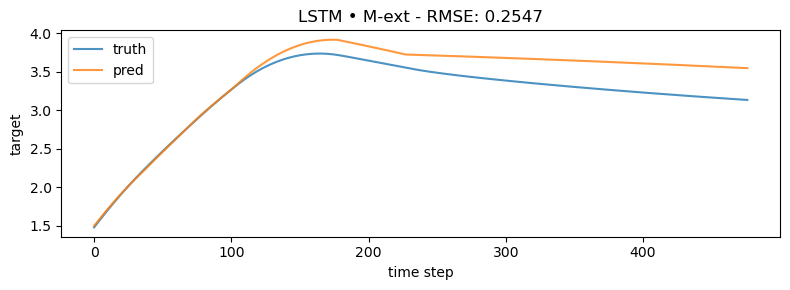

In [23]:
def rmse(a, b): return float(jnp.sqrt(jnp.mean((jnp.asarray(a)-jnp.asarray(b))**2)))

for (X, y_sim, scen) in train_data[:3]:
    # pull the original target from run_fair (if aligned)
    y_fair = jnp.asarray(delT_dict_tier1[scen], dtype=jnp.float32)[:y_sim.shape[0]]
    print(f"{scen:30s}  RMSE(sim vs run_fair): {rmse(y_sim, y_fair):.4f} K")

# 6.c) Scale with train stats and reshape for your LSTM (timesteps=1)
train_s, test_s, stats = split_and_scale(train_data, test_data)

# Example: take one scenario and prepare for your Keras LSTM
(Xs, y, scen) = train_s[0]
X_for_lstm = Xs.reshape((Xs.shape[0], 1, Xs.shape[1]))  # [samples, timesteps=1, features=2]
print(scen, "X_for_lstm:", X_for_lstm.shape, "y:", y.shape)

Xtr = jnp.concatenate([X for (X, _, _) in train_s], axis=0).astype(jnp.float32)  # (N, 4)
ytr = jnp.concatenate([y for (_, y, _) in train_s], axis=0).astype(jnp.float32)

key    = jax.random.PRNGKey(0)
in_dim = Xtr.shape[1]
hidden = 32

params0 = init_lstm_params(key, in_dim=in_dim, hidden=hidden, out_dim=1, dtype=jnp.float32)

train_unrolled_lstm_jit = jax.jit(train_unrolled_lstm, static_argnames=("K",))
paramsK, losses = train_unrolled_lstm_jit(params0, Xtr, ytr, K=500, lr=1e-2, weight_decay=1e-1)
(Xs_demo, y_demo, scen_demo) = test_s[2]
plot_lstm_predictions(paramsK, Xs_demo, y_demo, metric="RMSE", title_prefix=f"LSTM • {scen_demo}")



In [24]:
# --- RMSE helpers ---
def rmse(pred, y):
    pred = pred.astype(jnp.float32)
    y    = y.astype(jnp.float32)
    return jnp.sqrt(jnp.mean((pred - y)**2))

def eval_test_rmse_by_scenario(params, test_list):
    """Returns list of (scenario_name, rmse_value) for all tests."""
    out = []
    for (Xte, yte, scen_name) in test_list:
        yhat = lstm_forward(params, Xte)
        out.append((scen_name, rmse(yhat, yte)))
    return out

# --- compute per-scenario RMSEs and the average ---
rmse_list = eval_test_rmse_by_scenario(paramsK, test_s)          # [(name, rmse_jnp), ...]
avg_rmse  = jnp.mean(jnp.stack([r for (_, r) in rmse_list]))

# Print results
for name, r in rmse_list:
    print(f"{name:30s}  RMSE = {float(r):.6f}")
print(f"\nAverage test RMSE across {len(rmse_list)} scenarios: {float(avg_rmse):.6f}")


historical                      RMSE = 0.022706
H-ext-OS                        RMSE = 0.121359
M-ext                           RMSE = 0.254690
ML-ext                          RMSE = 1.652336
L-ext                           RMSE = 0.051336
VLHO-ext                        RMSE = 0.430840

Average test RMSE across 6 scenarios: 0.422211


In [25]:
from jax import tree as _jtree
_tree_map    = _jtree.map
def train_unrolled_lstm_sgd(params0, Xtr, ytr, K=50, lr=5e-4, weight_decay=0.0):
    pdt = params0["W"].dtype
    Xtr = Xtr.astype(pdt); ytr = ytr.astype(pdt)

    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.add_decayed_weights(weight_decay),
        optax.sgd(lr)   # plain SGD = ultra-stable backward
    )
    opt_state = optimizer.init(params0)

    def step(carry, i):
        params, opt_state = carry
        def loss_fn(p):
            yhat = lstm_forward(p, Xtr)
            return jnp.mean((yhat - ytr)**2)
        loss, grads = jax.value_and_grad(loss_fn)(params)
        grads = _tree_map(lambda g: jnp.nan_to_num(g, nan=0.0, posinf=1e6, neginf=-1e6), grads)
        updates, opt_state = optimizer.update(grads, opt_state, params=params)
        params = optax.apply_updates(params, updates)
        return (params, opt_state), loss

    (paramsK, opt_stateK), losses = jax.lax.scan(step, (params0, opt_state), xs=jnp.arange(K), length=K)
    return paramsK, losses


In [26]:
def make_objective_over_emissions_2g(
    scen_name_tr1,
    train_data, test_data,
    emis_dict_tier1,
    params0,
    historical_name="historical",
    dtype=jnp.float32
):
    # Pull historical (if present)
    years_hist, E_hist_co2, E_hist_ch4 = (None, None, None)
    if historical_name in emis_dict_tier1:
        years_hist, E_hist_co2, E_hist_ch4 = extract_years_and_E_co2_ch4(emis_dict_tier1[historical_name])
        years_hist   = jnp.asarray(years_hist,   dtype=dtype)
        E_hist_co2   = jnp.asarray(E_hist_co2,   dtype=dtype)
        E_hist_ch4   = jnp.asarray(E_hist_ch4,   dtype=dtype)

    # Current scenario years (emissions provided at call time)
    years_cur, _E_ignore_co2, _E_ignore_ch4 = extract_years_and_E_co2_ch4(emis_dict_tier1[scen_name_tr1])
    years_cur = jnp.asarray(years_cur, dtype=dtype)
    needs_history = (scen_name_tr1 != historical_name)

    def objective_over_emissions_2g(inputs_tuple):
        E_gtco2_train_scen, E_mtch4_train_scen = inputs_tuple
        E_gtco2_train_scen = jnp.asarray(E_gtco2_train_scen, dtype=dtype).reshape(-1)
        E_mtch4_train_scen = jnp.asarray(E_mtch4_train_scen, dtype=dtype).reshape(-1)

        # 1) Features for chosen training scenario
        X_tr1_new = make_features_E_and_cum_co2_ch4(
            E_gtco2_curr=E_gtco2_train_scen,
            E_mtch4_curr=E_mtch4_train_scen,
            E_gtco2_hist=E_hist_co2 if needs_history else None,
            E_mtch4_hist=E_hist_ch4 if needs_history else None
        )

        # 2) Targets from two-gas simulator (GMST)
        y_tr1_new = simulate_targets_gmst_from_co2_ch4(
            years_curr=years_cur,
            E_gtco2_curr=E_gtco2_train_scen,
            E_mtch4_curr=E_mtch4_train_scen,
            years_hist=years_hist if needs_history else None,
            E_gtco2_hist=E_hist_co2 if needs_history else None,
            E_mtch4_hist=E_hist_ch4 if needs_history else None
        ).astype(dtype)

        # 3) Rebuild full training dataset (this scen updated, others fixed)
        train_dataset_updated = [(X_tr1_new, y_tr1_new, scen_name_tr1)]
        for (X, y, scen) in train_data:
            if scen == scen_name_tr1:
                continue
            train_dataset_updated.append((jnp.asarray(X, dtype=dtype),
                                          jnp.asarray(y, dtype=dtype),
                                          scen))

        # 4) Scale with updated train stats; apply to tests
        train_s_updated, test_s_updated, _stats = split_and_scale(
            train_dataset_updated, test_data
        )

        # 5) Concatenate updated train tensors
        Xtr_u = jnp.concatenate([X for (X, _, _) in train_s_updated], axis=0).astype(dtype)
        ytr_u = jnp.concatenate([y for (_, y, _) in train_s_updated], axis=0).astype(dtype)

        # 6) Train inner LSTM
        paramsK_u, _ = train_unrolled_lstm_sgd(params0, Xtr_u, ytr_u, K=1000, lr=5e-2, weight_decay=1e-4)

        # 7) Evaluate mean test MSE
        return eval_on_tests_lstm(paramsK_u, test_s_updated).astype(dtype)

    return objective_over_emissions_2g


In [30]:
scen_name_tr1 = 'historical'
years_tr1, E0_co2, E0_ch4 = extract_years_and_E_co2_ch4(emis_dict_tier1[scen_name_tr1])
E0_co2 = jnp.asarray(E0_co2, dtype=jnp.float32)
E0_ch4 = jnp.asarray(E0_ch4, dtype=jnp.float32)

objective_over_emissions_2g = make_objective_over_emissions_2g(
    scen_name_tr1=scen_name_tr1,
    train_data=train_data,
    test_data=test_data,
    emis_dict_tier1=emis_dict_tier1,
    params0=params0,
    historical_name="historical",
    dtype=jnp.float32
)

# gradients wrt both series:
val, (g_co2, g_ch4) = jax.value_and_grad(objective_over_emissions_2g, argnums=0, has_aux=False)((E0_co2, E0_ch4))

# Gradient check (should be non-zero)
print("||grad_co2||:", float(jnp.linalg.norm(g_co2)))
print("||grad_ch4||:", float(jnp.linalg.norm(g_ch4)))


||grad_co2||: 0.000805970630608499
||grad_ch4||: 5.4305226512951776e-05


In [67]:
def build_train_from_U_2g(U_gtco2, U_mtch4):
    """
    Returns a single-scenario train dataset:
      [(X, y, 'opt_scen')], where X has 4 cols (CO2 prev,cum; CH4 prev,cum)
      and y is GMST from the two-gas simulator aligned to current timeline.
    """
    Uc = jnp.asarray(U_gtco2, dtype=jnp.float32).reshape(-1)
    Um = jnp.asarray(U_mtch4, dtype=jnp.float32).reshape(-1)
    assert Uc.shape[0] == Um.shape[0], "CO2 and CH4 series must have same length"
    years_cur = jnp.arange(Uc.shape[0], dtype=jnp.float32)

    X = make_features_E_and_cum_co2_ch4(
        E_gtco2_curr=Uc, E_mtch4_curr=Um,
        E_gtco2_hist=None, E_mtch4_hist=None
    )
    y = simulate_targets_gmst_from_co2_ch4(
            years_curr=years_cur,
            E_gtco2_curr=Uc, E_mtch4_curr=Um,
            years_hist=None, E_gtco2_hist=None, E_mtch4_hist=None
        ).astype(jnp.float32)

    N = jnp.minimum(X.shape[0], y.shape[0])
    return [(X[:N], y[:N], "opt_scen")]

def build_dataset_no_history_2g(emis_dict, scenarios):
    return build_dataset_from_runfair_dict_2g(
        emis_dict, scenarios, historical_name="__NONE__"
    )

def build_test_all_sets_2g(
    emis_dict_tier1, scenarios_tier1,
    emis_dict_tier2, scenarios_tier2,
    emis_dict_deck,  scenarios_deck_subset,
    historical_name="historical",
):
    test_t1   = build_dataset_from_runfair_dict_2g(emis_dict_tier1, scenarios_tier1, historical_name=historical_name)
    test_t2   = build_dataset_from_runfair_dict_2g(emis_dict_tier2, scenarios_tier2,  historical_name=historical_name, skip_hist=True)
    test_deck = build_dataset_no_history_2g(emis_dict_deck, scenarios_deck_subset)
    return test_t1 + test_t2 + test_deck



In [78]:
def init_gaussian_emissions(
    T: int,
    peak_emis: float = 50.0,   # peak emissions (GtCO2/yr)
    mu: float = 350.0,          # center of the Gaussian (years since start)
    sigma: float = 100.0,        # width (years); larger = broader peak
    floor: float = 0.0,         # baseline before/after the bump
    dtype=jnp.float32,
) -> jnp.ndarray:
    """
    Gaussian-shaped initial emissions path:
        E(t) = floor + peak * exp(-0.5 * ((t - mu)/sigma)^2)

    Choose mu > 200 and a moderate sigma to keep early years near zero.
    """
    t = jnp.arange(T, dtype=dtype)
    z = (t - jnp.array(mu, dtype=dtype)) / jnp.array(sigma, dtype=dtype)
    E = floor + jnp.array(peak_emis, dtype=dtype) * jnp.exp(-0.5 * z * z)
    return jnp.maximum(jnp.nan_to_num(E, nan=0.0, posinf=0.0, neginf=0.0), 0.0).astype(dtype)


Found 100, starting from here...


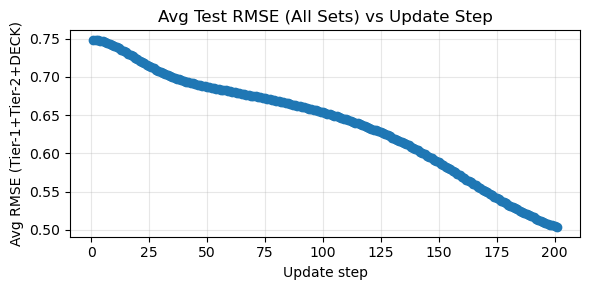

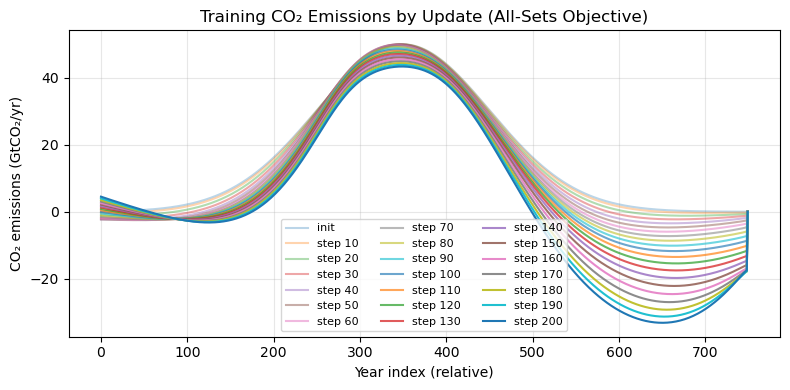

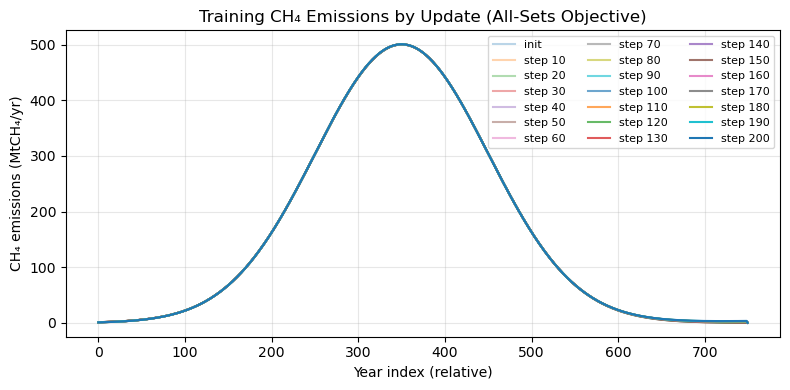

In [91]:
def make_time_weights(T: int, power: float = 2.0, min_scale: float = 0.1) -> jnp.ndarray:
    """
    0..1 ramp^power, then mapped to [min_scale, 1]. Early years get smaller steps.
    """
    x = jnp.linspace(0.0, 1.0, T)
    w = x ** power
    return min_scale + (1.0 - min_scale) * w  # shape (T,)

def avg_rmse_over_tests(params, test_list):
    # Compute per-scenario RMSE then average
    rmses = []
    for (Xte, yte, _) in test_list:
        yhat = lstm_forward(params, Xte)
        rmse_s = jnp.sqrt(jnp.mean((yhat - yte) ** 2))
        rmses.append(rmse_s)
    return jnp.mean(jnp.stack(rmses)) if rmses else jnp.array(0.0, dtype=jnp.float32)

# -- Objective(U): train on U, evaluate mean RMSE over ALL sets ---------------
def make_inverse_objective_single_train_allsets(
    params0,                  # LSTM init params (arrays)
    test_dataset_all,         # Tier-1 + Tier-2 + DECK-subset
    K_inner=50,
    lr_inner=5e-4,
    wd_inner=1e-4,
):
    def objective(U_pair):
        U_co2, U_ch4 = U_pair  # both (T,)
        # 1) Single training scenario from U (now two-gas)
        train_updated = build_train_from_U_2g(U_co2, U_ch4)

        # 2) Scale with updated train stats; apply to ALL tests
        train_s, test_s, _stats = split_and_scale(train_updated, test_dataset_all)

        # 3) Concatenate train tensors
        Xtr = jnp.concatenate([X for (X, _, _) in train_s], axis=0).astype(jnp.float32)
        ytr = jnp.concatenate([y for (_, y, _) in train_s], axis=0).astype(jnp.float32)

        # 4) Inner training (unchanged)
        paramsK, _ = train_unrolled_lstm_sgd(
            params0, Xtr, ytr, K=K_inner, lr=lr_inner, weight_decay=wd_inner
        )

        # 5) Return average RMSE across ALL scenarios
        loss = avg_rmse_over_tests(paramsK, test_s)
        aux  = (paramsK, test_s)

        return loss, aux
    return objective

# ====== Checkpoint utils (drop-in) ===========================================
import os, pickle, numpy as np
from functools import partial

def _tree_to_numpy(tree):
    return jax.tree_util.tree_map(
        lambda x: np.asarray(jax.device_get(x)) if isinstance(x, (jnp.ndarray, jax.Array)) else x, tree
    )

def _tree_to_jnp(tree):
    return jax.tree_util.tree_map(
        lambda x: jnp.asarray(x) if isinstance(x, np.ndarray) else x, tree
    )

def save_inverse_ckpt(path, state):
    """
    state keys (suggested):
      - "U_traj": list of jnp arrays (length = updates_done+1, includes init)
      - "errors": list/array of floats (same length as U_traj)
      - "opt_state": optax optimizer state PyTree
      - "step_count": int (number of completed updates)
      - "time_weights": jnp array or None
      - "meta": dict with hyperparams (to sanity-check resume)
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    safe = {
        "U_traj": [_tree_to_numpy(u) for u in state["U_traj"]],
        "errors": np.asarray(state["errors"]),
        "opt_state": _tree_to_numpy(state["opt_state"]),
        "step_count": int(state["step_count"]),
        "time_weights": _tree_to_numpy(state.get("time_weights", None)),
        "meta": state.get("meta", {}),
    }
    with open(path, "wb") as f:
        pickle.dump(safe, f)

def load_inverse_ckpt(path):
    with open(path, "rb") as f:
        raw = pickle.load(f)
    out = {
        "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
        "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
        "opt_state": _tree_to_jnp(raw["opt_state"]),
        "step_count": int(raw["step_count"]),
        "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
        "meta": raw.get("meta", {}),
    }
    return out

def optimize_emissions_inverse_allsets(
    emis_dict_tier1, scenarios_tier1,
    emis_dict_tier2, scenarios_tier2,
    emis_dict_deck,  scenarios_deck_subset,
    params0,
    num_updates=20,
    step_size=1e-1,            # LR applied to BOTH gases (use multi_transform for per-gas LRs)
    momentum=0.9,
    nesterov=True,
    K_inner=50,
    lr_inner=5e-4,
    wd_inner=1e-4,
    historical_name="historical",
    # --- checkpoint options ---
    checkpoint_path=None,
    checkpoint_every=10,
    resume_if_exists=True,
    save_preds=True,
    preds_every=1,          # save every k steps
    save_preds_in_ckpt=False,
):
    # Build combined test dataset (Tier-1 + Tier-2 + DECK-subset) -- 2-gas
    test_dataset_all = build_test_all_sets_2g(
        emis_dict_tier1, scenarios_tier1,
        emis_dict_tier2, scenarios_tier2,
        emis_dict_deck,  scenarios_deck_subset,
        historical_name=historical_name,
    )

    # Objective(U_co2, U_ch4): mean RMSE across ALL scenarios
    objective = make_inverse_objective_single_train_allsets(
        params0, test_dataset_all,
        K_inner=K_inner, lr_inner=lr_inner, wd_inner=wd_inner
    )
    loss_and_grad = jax.value_and_grad(objective, has_aux=True)

    # Define optimizer (must match across resume runs)
    T = 750

    # OPTIONAL: per-gas time weights (same shapes as U leaves)
    def make_time_weights_pair(T, power=2.0, min_scale=0.15):
        w = make_time_weights(T=T, power=power, min_scale=min_scale)  # (T,)
        return (w, w)  # same weights for both gases; change if you want different shapes/values

    time_weights = make_time_weights_pair(T=T, power=2.0, min_scale=0.15)

    # Per-leaf scaling transform (scales gradients elementwise like your original)
    def scale_by_coord_pytree(weights_pytree):
        def _mul(g, w): return g * w
        def init_fn(_): return ()
        def update_fn(updates, state, params=None):
            return jax.tree_util.tree_map(_mul, updates, weights_pytree), state
        return optax.GradientTransformation(init_fn, update_fn)

    opt = optax.chain(
        optax.clip_by_global_norm(1.0),
        scale_by_coord_pytree(time_weights),       # or remove this line if you don't want time weighting
        optax.sgd(learning_rate=step_size, momentum=momentum, nesterov=nesterov),
    )

    # Try to resume from checkpoint
    updates_done = 0
    preds_traj = []
    if resume_if_exists and checkpoint_path and os.path.isfile(checkpoint_path):
        ckpt = load_inverse_ckpt(checkpoint_path)
        U_traj   = ckpt["U_traj"]                # list of PyTrees
        errors   = ckpt["errors"].tolist()
        U_pair   = U_traj[-1]                    # last (U_co2, U_ch4)
        opt_state = ckpt["opt_state"]
        updates_done = ckpt["step_count"]
        print(f'Found {updates_done}, starting from here...')
    else:
        # Fresh start: initialize U and opt_state
        U_pair = (
            init_gaussian_emissions(T=T),
            init_gaussian_emissions(T=T, peak_emis=500),
        )
        (loss0, aux0), g0 = loss_and_grad(U_pair)
        paramsK0, test_s0 = aux0
        # Initial evaluation
        rmse0 = float(loss0)
        opt_state = opt.init(U_pair)
        U_traj = [U_pair]
        errors = [rmse0]
        updates_done = 0
        print('No checkpoint found, starting fresh...')
        if save_preds and (0 % preds_every == 0):
            preds0 = preds_by_scenario(paramsK0, test_s0)
            preds_traj.append(preds0)

    # Run only the remaining updates if resuming
    remaining = max(0, num_updates - updates_done)
    for k in range(remaining):
        (loss_k, aux_k), gU = loss_and_grad(U_pair)
        paramsK_k, test_s_k = aux_k

        updates, opt_state = opt.update(gU, opt_state, params=U_pair)
        U_pair = optax.apply_updates(U_pair, updates)
        rmse_k = float(loss_k)
        errors.append(rmse_k)
        U_traj.append(U_pair)
        updates_done += 1

        # Save predictions this step (optional)
        if save_preds and (updates_done % preds_every == 0):
            preds_k = preds_by_scenario(paramsK_k, test_s_k)
            preds_traj.append(preds_k)

        # periodic checkpoint
        if checkpoint_path and ((updates_done % checkpoint_every) == 0):
            state = {
                "U_traj": U_traj,
                "errors": errors,
                "opt_state": opt_state,
                "step_count": updates_done,
                "time_weights": time_weights,
                "meta": dict(step_size=step_size, momentum=momentum, nesterov=nesterov,
                             K_inner=K_inner, lr_inner=lr_inner, wd_inner=wd_inner, T=T),
            }
            if save_preds_in_ckpt:
                # Be aware this can be LARGE; tuples include strings + arrays.
                state["preds_traj"] = [
                    [(sc, np.asarray(jax.device_get(yh)), np.asarray(jax.device_get(yt)))
                     for (sc, yh, yt) in step_list]
                    for step_list in preds_traj
                ]
            save_inverse_ckpt(checkpoint_path, state)

    # Final snapshot (always save if path provided)
    if checkpoint_path:
        state = {
            "U_traj": U_traj,
            "errors": errors,
            "opt_state": opt_state,
            "step_count": updates_done,
            "time_weights": time_weights,
            "meta": dict(step_size=step_size, momentum=momentum, nesterov=nesterov,
                         K_inner=K_inner, lr_inner=lr_inner, wd_inner=wd_inner, T=T),
        }
        if save_preds_in_ckpt:
            state["preds_traj"] = [
                [(sc, np.asarray(jax.device_get(yh)), np.asarray(jax.device_get(yt)))
                 for (sc, yh, yt) in step_list]
                for step_list in preds_traj
            ]
        save_inverse_ckpt(checkpoint_path, state)

    # (Optional) final eval/preds if you have a convenience helper
    # _rmse_final, preds_final, _paramsKf = _train_inner_and_preds(...)

    return {
        "U_traj": U_traj,                              # list of (U_co2, U_ch4)
        "errors": jnp.asarray(errors, jnp.float32),    # avg RMSE per update (includes initial)
        "updates_done": updates_done,
        "checkpoint_path": checkpoint_path,
        "preds_traj": preds_traj,
    }

import matplotlib.pyplot as plt
# -- Optional: slightly tweaked title for the combined-sets plot --------------
def plot_inverse_results_allsets(results):
    errors = jnp.asarray(results["errors"])
    U_traj = results["U_traj"]

    # Error vs update
    plt.figure(figsize=(6,3))
    plt.plot(jnp.arange(1, errors.shape[0]+1), errors, marker='o')
    plt.xlabel("Update step"); plt.ylabel("Avg RMSE (Tier-1+Tier-2+DECK)")
    plt.title("Avg Test RMSE (All Sets) vs Update Step")
    plt.grid(True, alpha=0.3); plt.tight_layout()

    # CO2 emissions evolution (GtCO2/yr)
    plt.figure(figsize=(8,4))
    for i, (U_co2, U_ch4) in enumerate(U_traj):
        if i % 10 == 0:  # keep as in your original
            alpha = 0.3 + 0.7 * (i / max(1, len(U_traj)-1))
            lbl = "init" if i == 0 else f"step {i}"
            plt.plot(jnp.asarray(U_co2), alpha=alpha, label=lbl)
    plt.xlabel("Year index (relative)")
    plt.ylabel("CO₂ emissions (GtCO₂/yr)")
    plt.title("Training CO₂ Emissions by Update (All-Sets Objective)")
    plt.legend(ncol=3, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # CH4 emissions evolution (MtCH4/yr)
    plt.figure(figsize=(8,4))
    for i, (U_co2, U_ch4) in enumerate(U_traj):
        if i % 10 == 0:
            alpha = 0.3 + 0.7 * (i / max(1, len(U_traj)-1))
            lbl = "init" if i == 0 else f"step {i}"
            plt.plot(jnp.asarray(U_ch4), alpha=alpha, label=lbl)
    plt.xlabel("Year index (relative)")
    plt.ylabel("CH₄ emissions (MtCH₄/yr)")
    plt.title("Training CH₄ Emissions by Update (All-Sets Objective)")
    plt.legend(ncol=3, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

def preds_by_scenario(params, test_list):
    """
    Returns a list of (scenario_name, yhat, ytrue) with JAX arrays.
    """
    out = []
    for (Xte, yte, scen) in test_list:
        yhat = lstm_forward(params, Xte)
        out.append((scen, yhat, yte))
    return out

results_allsets = optimize_emissions_inverse_allsets(
    emis_dict_tier1=emis_dict_tier1, scenarios_tier1=scenarios_tier1,
    emis_dict_tier2=emis_dict_tier2, scenarios_tier2=scenarios_tier2,
    emis_dict_deck=emis_dict_DECK,   scenarios_deck_subset=scenarios_DECK_subset,
    params0=params0,
    num_updates=1600,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=200,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path="checkpoints/inverse_allsets_co2+ch4.pkl",
    checkpoint_every=10,
    resume_if_exists=True,
    save_preds=True,
    preds_every=10,          # save every k steps
    save_preds_in_ckpt=True,
)
plot_inverse_results_allsets(results_allsets)


In [72]:
def plot_preds_at_step(results, step_idx=0, max_scenarios=16, metric="RMSE"):
    preds_list = results["preds_traj"][step_idx]  # [(scen, yhat, ytrue), ...]
    for (scen, yhat, ytrue) in preds_list[:max_scenarios]:
        yhat_np = np.asarray(yhat); y_np = np.asarray(ytrue)
        if metric.upper() == "RMSE":
            score = float(jnp.sqrt(jnp.mean((yhat - ytrue)**2)))
            title = f"{scen} • RMSE={score:.3f}"
        else:
            score = float(jnp.mean((yhat - ytrue)**2))
            title = f"{scen} • MSE={score:.3f}"
        plt.figure(figsize=(7,2.5))
        plt.plot(y_np,   label="truth", alpha=0.8)
        plt.plot(yhat_np,label="pred",  alpha=0.8)
        plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

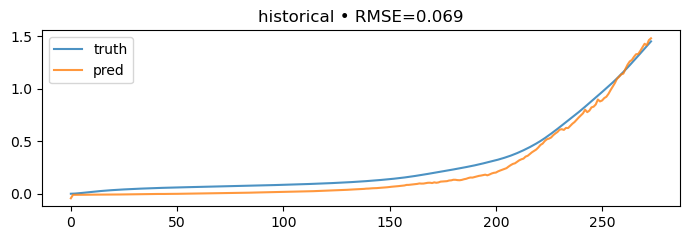

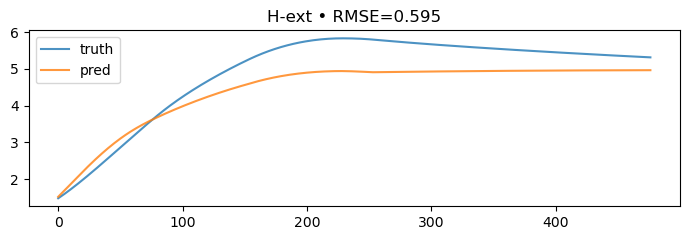

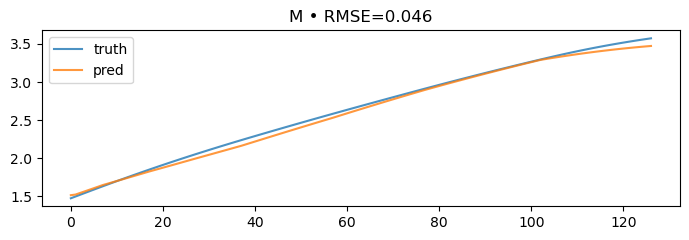

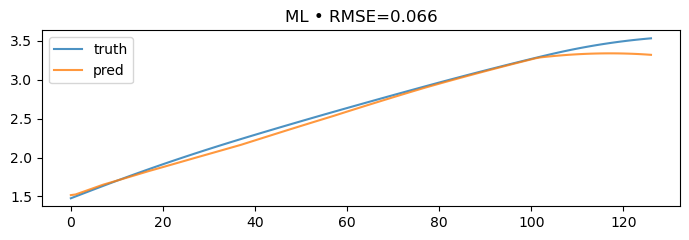

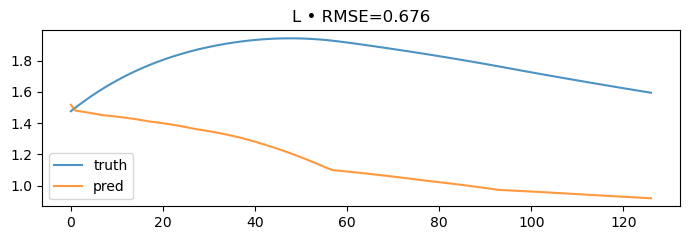

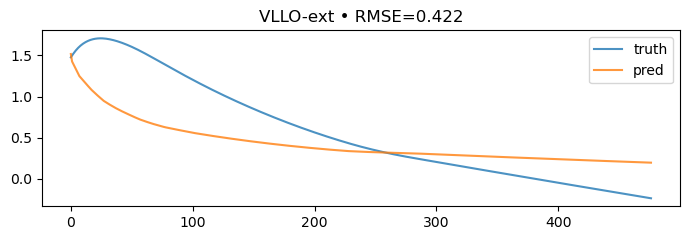

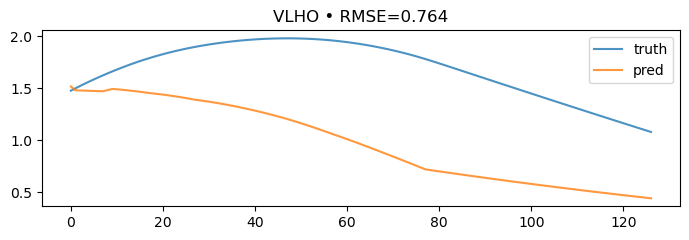

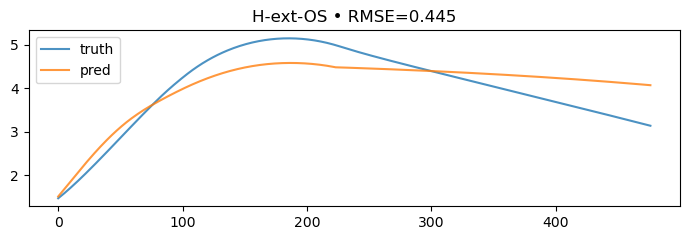

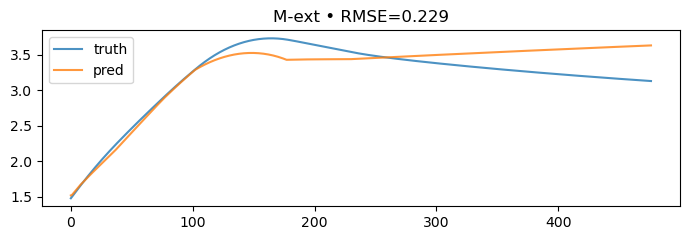

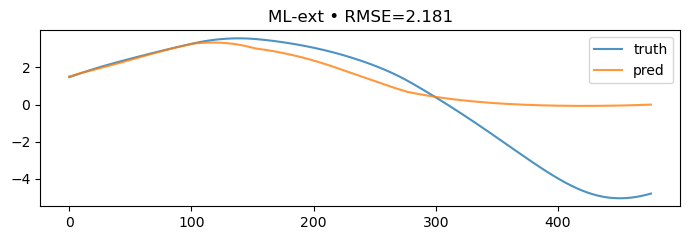

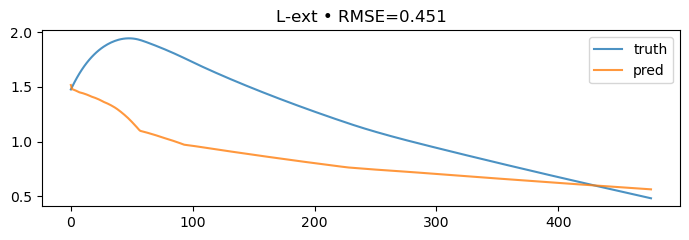

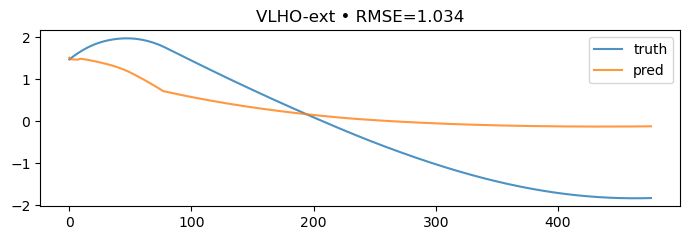

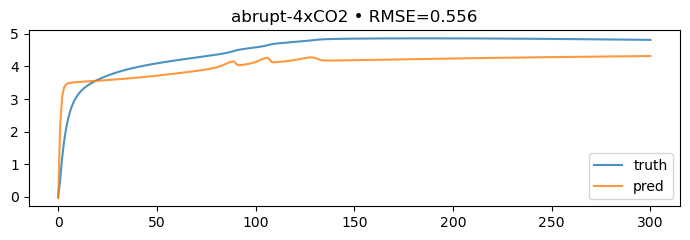

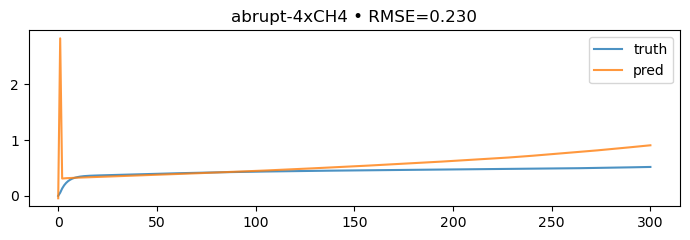

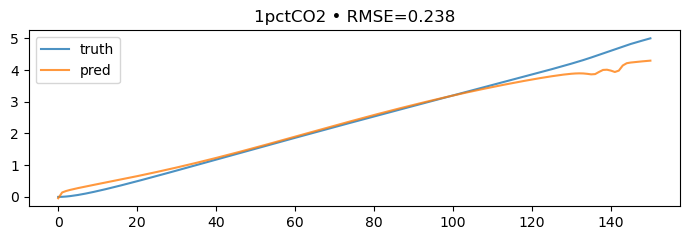

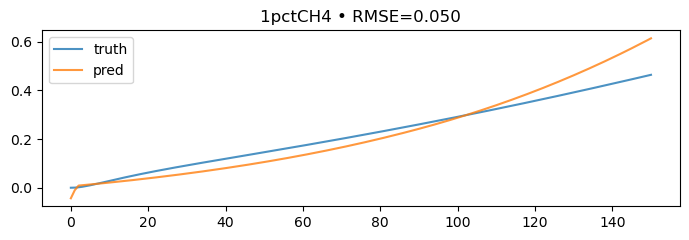

In [93]:
plot_preds_at_step(results_allsets, step_idx=-1)

In [75]:
len(results_allsets['preds_traj'])

2